# Train and Tune Random Forest Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.models.factory import Experiment
from src.models.random_forest import RandomForest
from src.plots import plot_forecast_diagnostics, plot_forecast_next_h, plot_test_overlay_h1, prep_h1_overlay, \
    prep_h_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

2025-08-26 19:11:32,519 - INFO - src.utils - Global random seed set to 42
2025-08-26 19:49:27,955 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
experiments = [
    Experiment(
        name="random_forest",
        build=lambda horizon, seed: RandomForest(horizon=horizon, random_state=seed),
        include_sentiment=True
    )
]

In [5]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_splits=4)

2025-08-26 19:49:28,342 - INFO - ModelTrainer - Initialized ModelTrainer for model: random_forest
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-08-26 19:49:28,343] A new study created in memory with name: no-name-5e2f0dde-a9ff-468c-8f44-49ec24a76ee8
2025-08-26 19:49:28,344 - INFO - ModelTrainer - Starting model tuning...
[I 2025-08-26 19:49:32,904] Trial 0 finished with value: 0.009160915094943588 and parameters: {'bootstrap': False, 'use_max_depth': True, 'n_estimators': 800, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 0.8}. Best is trial 0 with value: 0.009160915094943588.

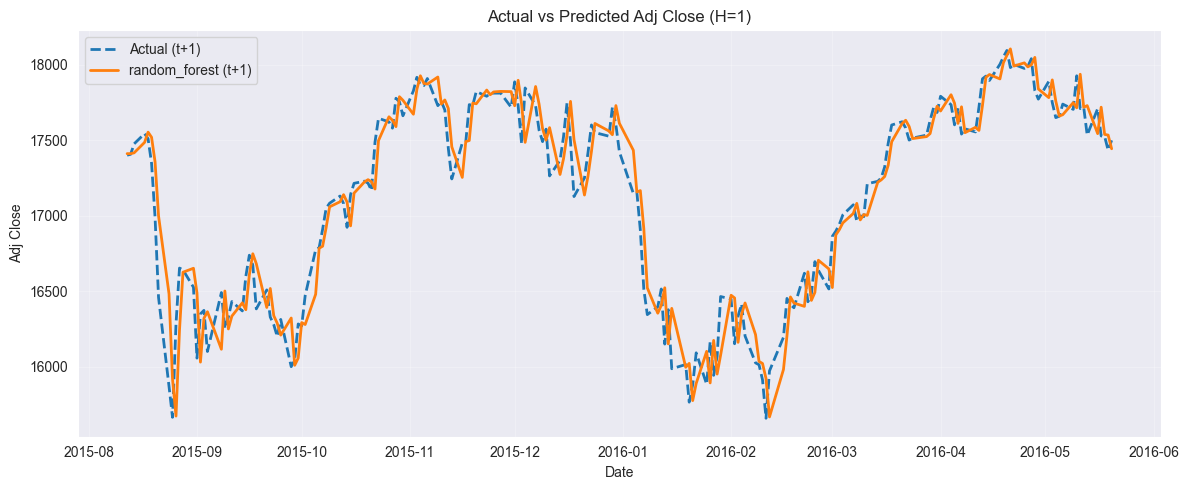

In [6]:
dates_next, actual_next, pred_next_by_model = prep_h1_overlay(df_full, results)
plot_test_overlay_h1(
    dates_next=dates_next,
    actual_next=actual_next,
    pred_next_by_model=pred_next_by_model,
    path=Path(cfg.data.fig_dir) / "random_forest_actual_vs_predicted_adj_close.png",
)

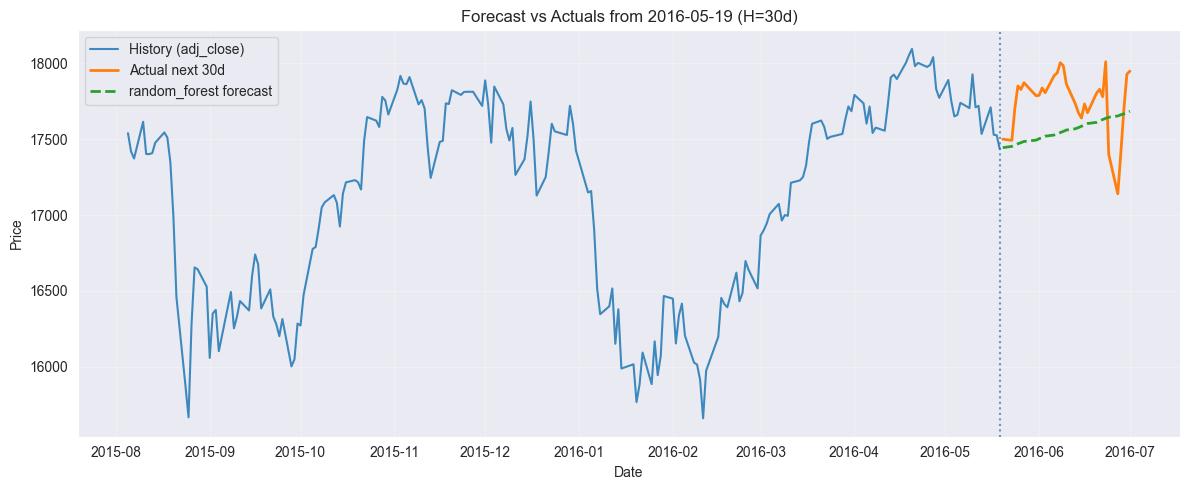

In [7]:
hist_dates, hist_prices, fut_dates, actual_path, anchor_date, paths_by_model = prep_h_overlay(df_full, results, HORIZON)
plot_forecast_next_h(
    hist_dates=hist_dates,
    hist_prices=hist_prices,
    fut_dates=fut_dates,
    forecast_paths_by_model=paths_by_model,
    actual_path=actual_path,
    anchor_date=anchor_date,
    H=HORIZON,
    path=Path(cfg.data.fig_dir) / "random_forest_forecast.png",
)

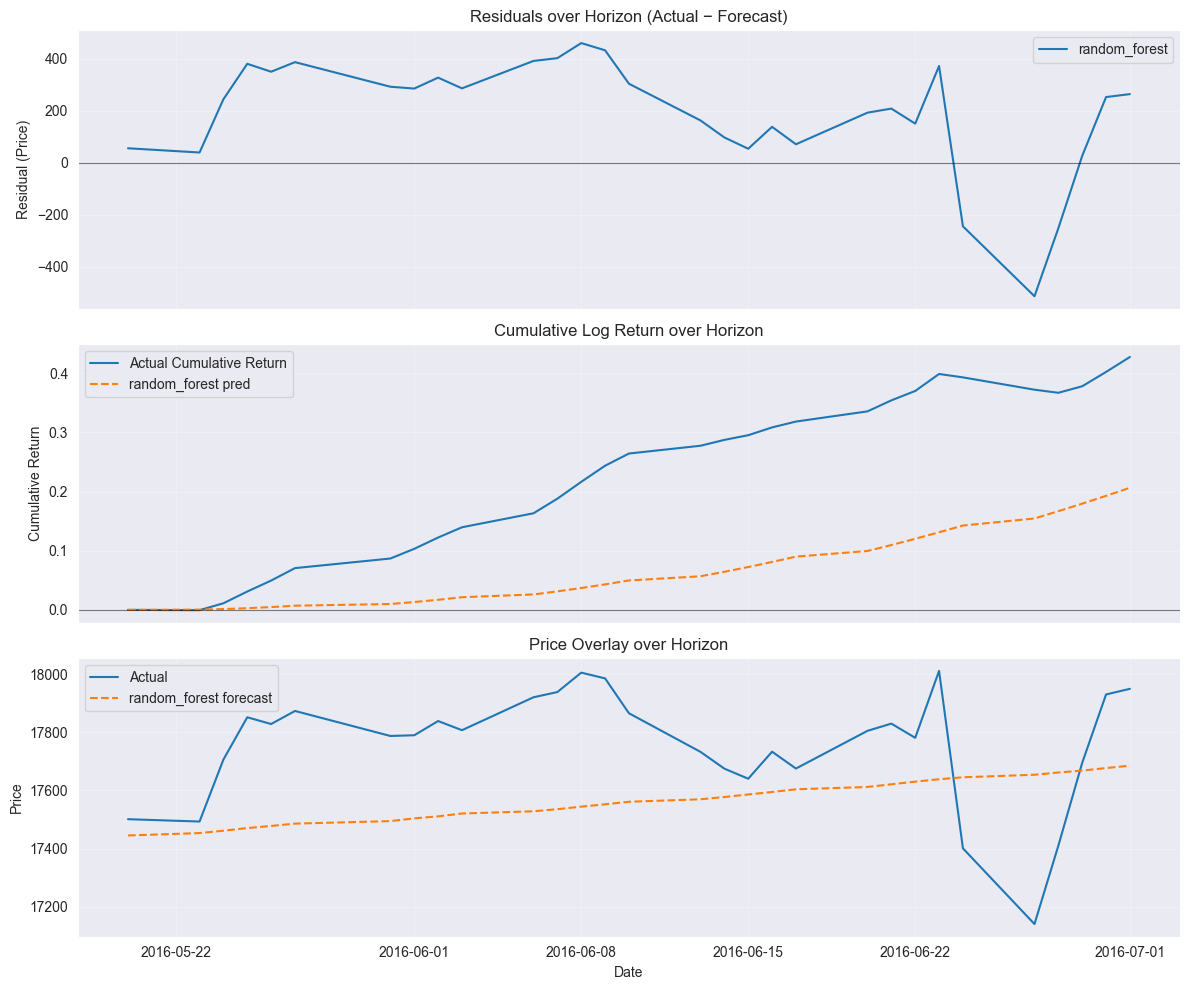

In [8]:
plot_forecast_diagnostics(
    fut_dates=fut_dates,
    actual_path=actual_path,
    forecast_paths_by_model=paths_by_model,
    path=Path(cfg.data.fig_dir) / "random_forest_forecast_diagnostics.png",
)

In [9]:
pd.DataFrame(results[0]["best_params"], index=[0])

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,max_samples,random_state
0,600,6,14,8,1.0,True,0.500017,42


In [10]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,0.007607,0.0001,0.009999,1.74243,-0.005693


In [11]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()
vis.plot_slice(study).show()
vis.plot_parallel_coordinate(study).show()
vis.plot_contour(study).show()
vis.plot_edf(study).show()

[W 2025-08-26 19:50:14,467] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,468] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,468] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,469] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,469] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,469] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,470] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,470] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,471] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,471] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,471] Param use_max_depth unique value length is less than 2.
[W 2025-08-26 19:50:14,472] Param use_max_depth unique value length is less 